# Annual numbers for programs


**HOW TO USE THIS JUPYTER NOTEBOOK:** highlight the cell by clicking on it. You should see a green or blue box surround it. Then hold the Shift key and press Enter. You should see the highlight box move on to the next cell, and it will print or plot whatever the code says to do.
Try it here. Click on the gray text box below to highlight the cell, then hold Shift and press Enter.

In [1]:
print("Hello world!")

Hello world!


If it says **Hello world!** to you below the gray cell, it worked!

## Import statements, classes, and methods. 
Run these (Shift, Enter) then keep going. They shouldn't spit anything out at you. If they do, tell Abbie.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme()
sns.set_style('whitegrid')
import matplotlib.pyplot as plt
from mplcursors import cursor
import ipywidgets as widgets
import traitlets
from IPython.display import display
from tkinter import Tk, filedialog


In [22]:
%matplotlib qt

In [4]:
class SelectFilesButton(widgets.Button):
    """A file widget that leverages tkinter.filedialog."""

    def __init__(self):
        super(SelectFilesButton, self).__init__()
        # Add the selected_files trait
        self.add_traits(files=traitlets.traitlets.List())
        # Create the button.
        self.description = "Select Files"
        self.icon = "square-o"
        self.style.button_color = "orange"
        # Set on click behavior.
        self.on_click(self.select_files)

    @staticmethod
    def select_files(b):
        """Generate instance of tkinter.filedialog.

        Parameters
        ----------
        b : obj:
            An instance of ipywidgets.widgets.Button 
        """
        # Create Tk root
        root = Tk()
        # Hide the main window
        root.withdraw()
        # Raise the root to the top of all windows.
        root.call('wm', 'attributes', '.', '-topmost', True)
        # List of selected fileswill be set to b.value
        b.files = filedialog.askopenfilename(multiple=True)

        b.description = "Files Selected"
        b.icon = "check-square-o"
        b.style.button_color = "lightgreen"    

In [5]:
def clean_up_df(raw_df):
    """ 
    This method takes a dataframe with program information like Name, Location, Date, Time, Capacity, 
    and two rows for Attended, one with a number for 'Yes' and another with a number for 'No'
    """
    clean_df = pd.DataFrame(columns=('Name', 'Series', 'Location', 'Date', 'Time', 'Day', 
                                         'Capacity', 'Preregistered', 'Attended', 'Percentage'))
    clean_df['Name'] = raw_df['Name'].unique()
    for i in range(len(clean_df)):
        namemask = raw_df.where(raw_df['Name'] == clean_df['Name'][i])
        fvi = namemask.first_valid_index()
        clean_df.loc[i, 'Series'] = namemask['Series'][fvi]
        clean_df.loc[i, 'Location'] = namemask['Location'][fvi]
        clean_df.loc[i, 'Date'] = pd.to_datetime(namemask['Date'][fvi])
        clean_df.loc[i, 'Time'] = namemask['Time'][fvi]
        clean_df.loc[i, 'Capacity'] = namemask['Capacity'][fvi]
        yes_fvi = namemask.where(namemask['Attended'] == "Yes").first_valid_index()
        if yes_fvi == None:
            clean_df.loc[i,'Attended'] = 0
        else:
            clean_df.loc[i, 'Attended'] = namemask['Number'][yes_fvi]
        no_fvi = namemask.where(namemask['Attended'] == "No").first_valid_index()
        if no_fvi == None:
            clean_df.loc[i, 'Preregistered'] = clean_df['Attended'][i]
        else:
            clean_df.loc[i, 'Preregistered'] = clean_df['Attended'][i] + namemask['Number'][no_fvi]
                                                                                        
    clean_df['Percentage'] = clean_df['Attended'] / clean_df['Preregistered']
    clean_df.sort_values(by="Date", inplace=True)
    clean_df['Day'] = [j.strftime('%a') for j in clean_df['Date']]
    return clean_df

In [6]:
def convert_yesno_to_bool(yesno):
    """ This method converts 'yes' and 'no' in an Altru excel file to boolean values."""
    if yesno.casefold() == "yes".casefold():
        return True
    elif yesno.casefold() == "no".casefold():
        return False
    else:
        return np.nan

In [7]:
def get_ci90(df, groupbything, columnthing):
    """ This method gets the 90% confidence interval for errors on a distribution. 
    Need to use with errorbar=('ci', 90) in the plots!"""
    n = len(df)
    means = df.groupby(groupbything, observed=False)[columnthing].mean()
    print("Means:")
    print(means)
    stddevs = df.groupby(groupbything, observed=False)[columnthing].std()
    ci90 = 1.645 * (stddevs / np.sqrt(n))
    print("90% errors:")
    print(ci90)

## Run the cell below, then click the button to select your data file to load. 

The code expects an .xlsx data file made in Altru with the 'Program Query: Food Fight!' ad-hoc query. This file makes columns for the program name, program location, program date and time, participant capacity as specified in Altru, number of spaces still available, then two rows for each program: one with the number of pre-registrants who attended, and one with the number of pre-registrants who did not.

In [8]:
# button1 = SelectFilesButton()
# button1  # This will display the button in the context of Jupyter Notebook

Run this next cell to assign that file name to a variable and read in the excel file, then make a Pandas Dataframe called `programs` with the cleaned data. It will print basic information about the `programs` dataframe.

In [9]:
prefix = "fy26-all"
q_dir = "./%s/" % (prefix)

In [10]:
# program_xlsx_file = button1.files[0]
program_xlsx_file = "%s/%s_programs.xlsx" % (q_dir, prefix)
raw_program_data = pd.read_excel(program_xlsx_file, engine='openpyxl')
if len(raw_program_data) % 2 != 0:
    print("WARNING: There are an odd number of lines in the program query data file. Please check the file in Excel to ensure that each program is listed twice, once with 'No' and once with 'Yes'. If you're missing a 'Yes' line (because nobody attended), copy the 'No' line, change 'No' to 'Yes', and change 'Number' to 0, and save the changes.")
else:
    programs = clean_up_df(raw_program_data)
    print(programs.info())

<class 'pandas.core.frame.DataFrame'>
Index: 37 entries, 21 to 18
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           37 non-null     object
 1   Series         37 non-null     object
 2   Location       37 non-null     object
 3   Date           37 non-null     object
 4   Time           37 non-null     object
 5   Day            37 non-null     object
 6   Capacity       37 non-null     object
 7   Preregistered  37 non-null     object
 8   Attended       37 non-null     object
 9   Percentage     37 non-null     object
dtypes: object(10)
memory usage: 3.2+ KB
None


If it's throwing an error, check the program query data file that each program has two lines, a line with "no" and a line with "yes". If you're missing a "yes" line (because nobody attended), copy the "no" line, change "no" to "yes", and change "number" to "0".

In [11]:
programs['Capacity'] = programs['Capacity'].astype(int)
programs['Preregistered'] = programs['Preregistered'].astype(int)
programs['Attended'] = programs['Attended'].astype(int)

In [12]:
programs = programs.sort_values(by='Date')

In [13]:
nope_idx = programs['Name'].str.casefold().str.contains('cancelled|postponed'.casefold())
programs.loc[nope_idx, 'Percentage'] = np.nan 

## Shortening program series names
rename_idx = programs['Series'].str.casefold().str.contains('Cultural Heritage'.casefold())
programs.loc[rename_idx, 'Series'] = "Cultural Heritage"
rename_idx = programs['Series'].str.casefold().str.contains('Native American'.casefold())
programs.loc[rename_idx, 'Series'] = "Cultural Heritage"
rename_idx = programs['Series'].str.casefold().str.contains('Speculative Futures'.casefold())
programs.loc[rename_idx, 'Series'] = "Spec Futures"
rename_idx = programs['Series'].str.casefold().str.contains('Blurred Realities'.casefold())
programs.loc[rename_idx, 'Series'] = "Blurred Realities"
rename_idx = programs['Series'].str.casefold().str.contains('Unwind'.casefold())
programs.loc[rename_idx, 'Series'] = "Unwind"
rename_idx = programs['Series'].str.casefold().str.contains('MSUFCU Arts Power Up'.casefold())
programs.loc[rename_idx, 'Series'] = "Arts Power Up"

## Shortening program names
programs['Name'] = [thing.replace("Speculative Futures | ", "") for thing in programs['Name']]

## Recategorizing some
rename_idx = programs['Series'].str.casefold().str.contains('Ascent'.casefold())
programs.loc[rename_idx, 'Series'] = "Other"
rename_idx = programs['Series'].str.casefold().str.contains('SciCurious'.casefold())
programs.loc[rename_idx, 'Series'] = "Other"
rename_idx = programs['Series'].str.casefold().str.contains('cadre'.casefold())
programs.loc[rename_idx, 'Series'] = "Other"
rename_idx = programs['Series'].str.casefold().str.contains('Hard Hat'.casefold())
programs.loc[rename_idx, 'Series'] = "Other"
rename_idx = programs['Series'].str.casefold().str.contains('CoLab'.casefold())
programs.loc[rename_idx, 'Series'] = "Other"
rename_idx = programs['Series'].str.casefold().str.contains('Education'.casefold())
programs.loc[rename_idx, 'Series'] = "Other"
rename_idx = programs['Series'].str.casefold().str.contains('Salt'.casefold())
programs.loc[rename_idx, 'Series'] = "Other"

In [14]:
#for i in range(len(programs)):
#    print("%s\t%s\t%d" % (programs.loc[i,'Date'].strftime("%-m/%-d/%y"), 
#                          programs.loc[i, 'Name'], 
#                          programs.loc[i, 'Attended']))
#display(programs)

If you have cancelled or postponed programs (or other reasons why the attendance percentage would be Not a Number), filter those out of what's going to be plotted.

In [15]:
nan_idx = programs['Percentage'].isnull()
programs = programs.loc[~nan_idx]

If the program series is ongoing, filter out the ones that haven't happened yet.

In [17]:
display(programs['Name'])

21                  "Physical Spells" Opening Reception
30                            Harvest Moon Silent Disco
25                         September cadre x MSU Museum
13    Beyond Borders: A Conversation with Dr. Fredri...
14    Beyond Borders: Oral History with Dr. Fredrick...
23                                        Hard Hat Tour
31                                       Move Your Way!
11                                   Ignite Talks MSU 5
32                           Unplug. Link up. Have fun.
15    Echoes of the Earth: Native American Drumming ...
26                          November cadre x MSU Museum
17    Echoes of the Earth: Native American Drumming ...
16    Echoes of the Earth: Native American Drumming ...
0     MSU Museum Reopening & "Blurred Realities" Exh...
1     Fake News! The Battle for Truth in a Disinform...
33                                New Year Silent Disco
2                Reality Check: Spotting AI Shenanigans
3                                   XOXO, Let's 

## Let's get some basic numbers!

In [18]:
print("There were %d registrants and %d attendees." % (programs['Preregistered'].sum(), programs['Attended'].sum()))

There were 5936 registrants and 3847 attendees.


In [19]:
#display(programs[['Name', 'Percentage', 'Attended']])

In [20]:
programs['Series'] = pd.Categorical(programs['Series'], ordered=True)

Plot the attendance of programs as a function of time! (this only looks good for a whole exhibition or year)

In [46]:
fig, ax = plt.subplots(figsize=(14,6))
fig = sns.scatterplot(data=programs.dropna(), x='Date', y='Percentage', hue='Series', palette="Set2")
x_dates = pd.date_range(start='9/2025', end='6/2026', freq='MS', inclusive='both')
point_labels = programs.sort_values(by='Date')['Name'].tolist()
ax.set_xticks(x_dates, labels=x_dates.strftime('%b %Y'), horizontalalignment='left')
ax.set(ylim=(0, 1.0), ylabel="Attendance fraction", xlabel="")
ax.legend(loc='lower left')

#cursor(ax, hover=True).connect("add", lambda sel: sel.annotation.set_text(point_labels[sel.index]))
# Hover over point to see program name - only works with '%matplotlib qt' set above

c2 = cursor(ax, hover=True)
@c2.connect("add")
def _(sel):
    sel.annotation.set_text(point_labels[sel.index])
    sel.annotation.get_bbox_patch().set(fc="white", ec=None, alpha=0.6)
    sel.annotation.set_fontweight('bold')
#    sel.annotation.set_color('black')

fig.figure.savefig(q_dir+"/program_attendance_timeline_scatter.png",bbox_inches='tight')
plt.show()

In [47]:
fig, ax = plt.subplots(figsize=(14,6))
fig = sns.scatterplot(data=programs.dropna(), x='Date', y='Attended', hue='Series', palette="Set2")
x_dates = pd.date_range(start='9/2025', end='6/2026', freq='MS', inclusive='both')
point_labels = programs.sort_values(by='Date')['Name'].tolist()
ax.set_xticks(x_dates, labels=x_dates.strftime('%b %Y'), horizontalalignment='left')
ax.set(ylim=(0,350), ylabel="Number of attendees", xlabel="")
ax.legend(loc='upper right')

# Hover over point to see program name - only works with '%matplotlib qt' set above
#cursor(ax, hover=True).connect("add", lambda sel: sel.annotation.set_text(point_labels[sel.index]))

c1 = cursor(ax, hover=True)
@c1.connect("add")
def _(sel):
    sel.annotation.set_text(point_labels[sel.index])
    sel.annotation.get_bbox_patch().set(fc="white", ec=None, alpha=0.6)
    sel.annotation.set_fontweight('bold')
#    sel.annotation.set_color('black')

fig.figure.savefig(q_dir+"/program_timeline_scatter.png",bbox_inches='tight')
plt.show()

Not pictured in second one: SciCurious with 850 attendees.

## Program series

In [48]:
print("Attendance fraction per program series:")
programs.groupby('Series', observed=False)['Percentage'].mean()

Attendance fraction per program series:


Series
Arts Power Up        0.538831
Blurred Realities    0.472874
Cultural Heritage    0.671567
Other                0.670162
Spec Futures         0.666643
Unwind               0.609336
Name: Percentage, dtype: object

## Program type

In [51]:
## Keywords to search for to allocate workshops, conversations, performances, and other not listed
workshops = 'workshop|shenanigans|ai-biographies|xoxo|salt|oral|afrofuturism'
conversations = 'conversation|talk|elections|alternative|battle|visual|apida'
performances = 'noise|clone|queer|poetry|ignite|feminine'
social = 'disco|reception|cadre|unplug|comic|move|ascent|love'

w_idx = programs['Name'].str.casefold().str.contains(workshops.casefold())
programs.loc[w_idx, 'Type'] = "Workshop"
c_idx = programs['Name'].str.casefold().str.contains(conversations.casefold())
programs.loc[c_idx, 'Type'] = "Conversation"
p_idx = programs['Name'].str.casefold().str.contains(performances.casefold())
programs.loc[p_idx, 'Type'] = "Performance"
s_idx = programs['Name'].str.casefold().str.contains(social.casefold())
programs.loc[s_idx, 'Type'] = "Social"
programs['Type'] = programs['Type'].fillna("Other")
nope_idx = programs['Name'].str.casefold().str.contains('cancelled|postponed'.casefold())
programs.loc[nope_idx,'Type'] = 'Other'
programs.loc[nope_idx, 'Percentage'] = np.nan

type_cats = ['Workshop', 'Conversation', 'Performance', 'Social', 'Other']
programs['Type'] = pd.Categorical(programs['Type'], categories=type_cats, ordered=True)

display(programs)

,Name,Series,Location,Date,Time,Day,Capacity,Preregistered,Attended,Percentage,Type
21,"""Physical Spells"" Opening Reception",Arts Power Up,311 Abbot,2025-09-04 00:00:00,4:00 PM,Thu,200.0,152.0,99.0,0.651316,Social
30,Harvest Moon Silent Disco,Unwind,Beal Botanical Garden,2025-09-05 00:00:00,7:00 PM,Fri,500.0,456.0,302.0,0.662281,Social
25,September cadre x MSU Museum,Other,311 Abbot,2025-09-20 00:00:00,6:00 PM,Sat,350.0,302.0,239.0,0.791391,Social
13,Beyond Borders: A Conversation with Dr. Fredri...,Cultural Heritage,WKAR,2025-10-02 00:00:00,5:00 PM,Thu,80.0,52.0,32.0,0.615385,Conversation
14,Beyond Borders: Oral History with Dr. Fredrick...,Cultural Heritage,Multicultural Center,2025-10-03 00:00:00,5:00 PM,Fri,500.0,38.0,21.0,0.552632,Workshop
23,Hard Hat Tour,Other,MSU Museum,2025-10-13 00:00:00,10:00 AM,Mon,1000.0,25.0,22.0,0.88,Other
31,Move Your Way!,Unwind,IM Circle,2025-10-17 00:00:00,7:00 PM,Fri,1000.0,57.0,30.0,0.526316,Social
11,Ignite Talks MSU 5,Other,311 Abbot,2025-10-29 00:00:00,7:00 PM,Wed,180.0,120.0,81.0,0.675,Performance
32,Unplug. Link up. Have fun.,Unwind,311 Abbot,2025-11-07 00:00:00,7:00 PM,Fri,500.0,82.0,52.0,0.634146,Social
15,Echoes of the Earth: Native American Drumming ...,Cultural Heritage,WKAR,2025-11-19 00:00:00,5:00 PM,Wed,121.0,119.0,56.0,0.470588,Conversation


In [52]:
get_ci90(programs.sort_values('Type'), 'Type', 'Percentage')

Means:
Type
Workshop        0.560259
Conversation    0.521953
Performance      0.53666
Social          0.647448
Other           0.816773
Name: Percentage, dtype: object
90% errors:
Type
Workshop        0.058204
Conversation    0.039159
Performance     0.022012
Social          0.018902
Other           0.024181
Name: Percentage, dtype: float64


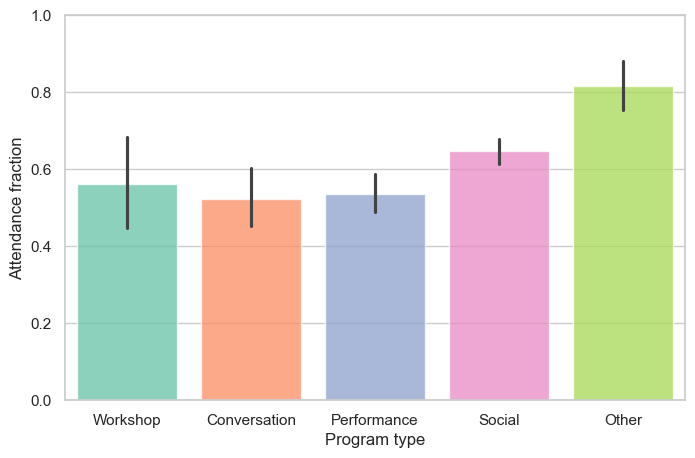

In [54]:
fig, ax = plt.subplots(figsize=(8,5))
fig = sns.barplot(data=programs.sort_values('Type'), x='Type', y='Percentage', palette='Set2', 
                  hue='Type', saturation=1, alpha=0.75, errorbar=('ci', 90))
ax.set(xlabel="Program type", ylabel="Attendance fraction", ylim=(0, 1.0))
fig.figure.savefig(q_dir+"program_type_bar.png", bbox_inches='tight')
plt.show()

## Program location

Rank the locations by number of programs held there.

In [22]:
loc_cats = programs['Location'].value_counts(ascending=False, dropna=True).index
programs['Location'] = pd.Categorical(programs['Location'], categories=loc_cats, ordered=True)


In [23]:
loc_mapping = {'MSU Museum': 'Museum', 
               '311 Abbot': '311 Abbot', 
               'WKAR': 'WKAR', 
               'Nokomis Cultural Heritage Center': 'Nokomis',
               'Beal Botanical Garden': 'Beal',
               'Multicultural Center': 'MCC',
               'IM Circle': 'IM Circle',
               'MSU Main Library': 'Library'}
programs['Location'] = programs['Location'].map(loc_mapping)

How was attendance of programs based on their location?

In [24]:
programs.groupby('Location', observed=False, dropna=True)['Percentage'].mean()

Location
Museum       0.553319
311 Abbot    0.692963
WKAR         0.542986
Nokomis      0.859615
Beal         0.662281
MCC          0.552632
IM Circle    0.526316
Library      0.511628
Name: Percentage, dtype: object

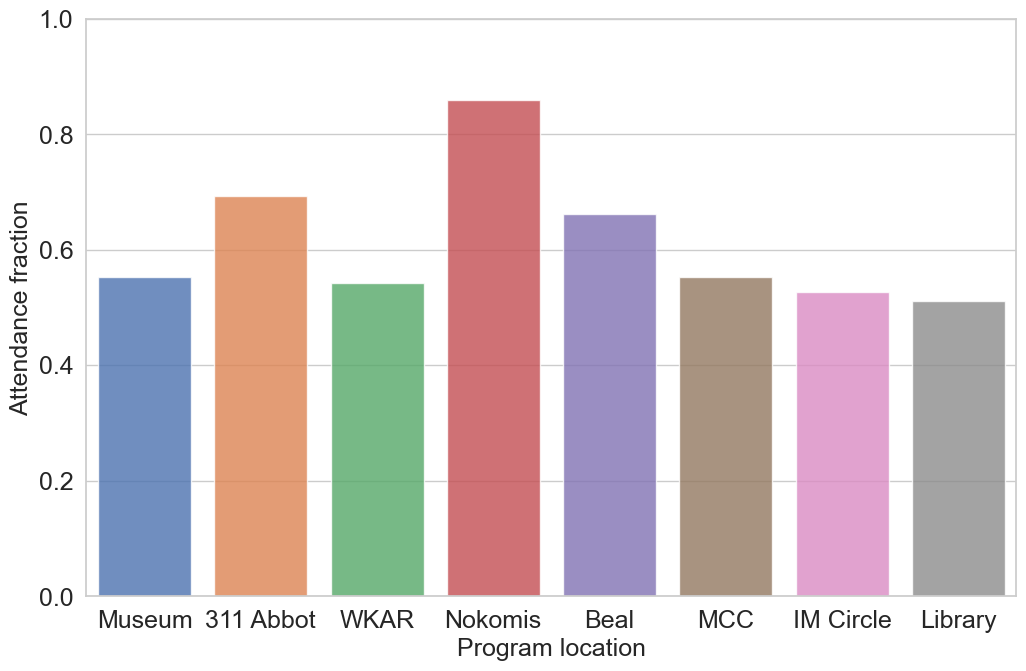

In [25]:
fig, ax = plt.subplots(figsize=(12,7.5))
sns.set_palette('deep')
fig = sns.barplot(data=programs, x='Location', y='Percentage', palette='deep', 
                  hue='Location', saturation=1, alpha=0.8, errorbar=None)
ax.set(xlabel="Program location", ylabel="Attendance fraction", ylim=(0,1))
ax.tick_params(axis='both', which='major', labelsize=18)
ax.xaxis.label.set_size(18)
ax.yaxis.label.set_size(18)
fig.figure.savefig(q_dir+"/program_location_bar.png", bbox_inches='tight')
plt.show()

## Time of day

In [26]:
get_ci90(programs.sort_values('Time'), 'Time', 'Percentage')

Means:
Time
10:00 AM        0.88
12:00 PM    0.558088
1:00 PM         0.95
2:00 PM        0.275
3:00 PM     0.849162
3:30 PM      0.64313
4:00 PM     0.651316
5:00 PM     0.546201
5:30 PM     0.452348
6:00 PM     0.672067
7:00 PM     0.578754
8:00 AM     0.769231
Name: Percentage, dtype: object
90% errors:
Time
10:00 AM         NaN
12:00 PM    0.047831
1:00 PM          NaN
2:00 PM          NaN
3:00 PM          NaN
3:30 PM          NaN
4:00 PM          NaN
5:00 PM     0.019637
5:30 PM     0.018504
6:00 PM     0.025908
7:00 PM     0.020265
8:00 AM          NaN
Name: Percentage, dtype: float64


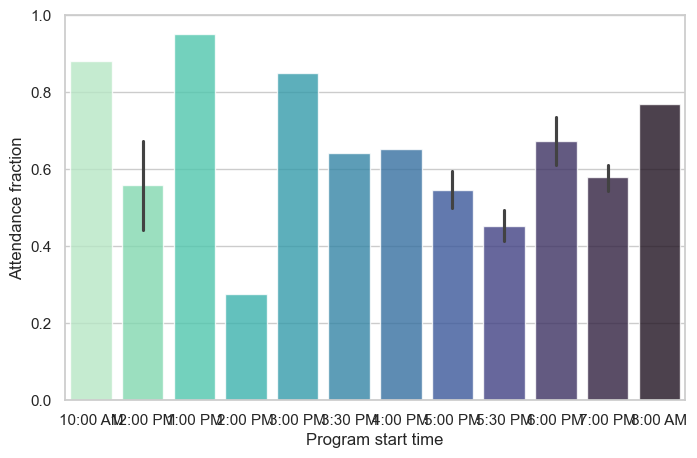

In [28]:
fig, ax = plt.subplots(figsize=(8,5))
fig = sns.barplot(data=programs.sort_values('Time'), x='Time', y='Percentage', palette='mako_r', 
                  hue='Time', saturation=1, alpha=0.8, errorbar=('ci', 90))
ax.set(xlabel="Program start time", ylabel="Attendance fraction", ylim=(0, 1.0))
fig.figure.savefig(q_dir+"/program_time_bar.png", bbox_inches='tight')
plt.show()

## Day of week

Sort days of the week in calendar order, not alphabetical order.

In [29]:
day_cats = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
programs['Day'] = pd.Categorical(programs['Day'], categories=day_cats, ordered=True)

In [30]:
get_ci90(programs.sort_values('Day'), 'Day', 'Percentage')

Means:
Day
Mon        0.88
Tue         NaN
Wed     0.58011
Thu    0.491387
Fri    0.607757
Sat    0.708688
Sun         NaN
Name: Percentage, dtype: object
90% errors:
Day
Mon         NaN
Tue         NaN
Wed    0.020070
Thu    0.023675
Fri    0.029929
Sat    0.061533
Sun         NaN
Name: Percentage, dtype: float64


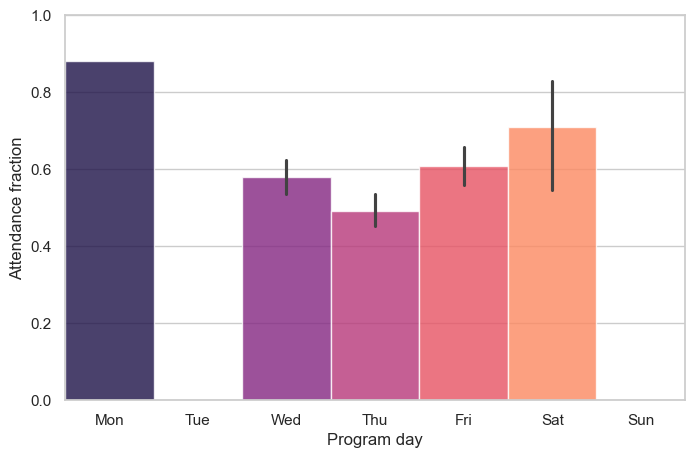

In [32]:
fig, ax = plt.subplots(figsize=(8,5))
fig = sns.barplot(data=programs.sort_values('Day'), x='Day', y='Percentage', palette='magma', 
                  hue='Day', saturation=1, alpha=0.8, width=1, dodge=False, errorbar=('ci', 90))
ax.set(xlabel="Program day", ylabel="Attendance fraction", ylim=(0, 1.0))
fig.figure.savefig(q_dir+"/program_day_bar.png", bbox_inches='tight')
plt.show()

# Program attendees

Now we can get nitty-gritty. Let's load in the data file with all the registrants for each program.

**VERY IMPORTANT NOTE:** You need to open the excel file and double-check that the non-MSU affiliation says "Not MSU" instaed of "None". Otherwise, having no MSU affiliation gets merged with the people for whom we don't have that information. If needed, do find-replace IN EXCEL to switch "None" to "Not MSU".

In [26]:
# button2 = SelectFilesButton()
# button2  # This will display the button in the context of Jupyter Notebook

In [27]:
# reg_xlsx_file = button2.files[0]
reg_xlsx_file = "%s/%s_registrants.xlsx" % (q_dir, prefix)

In [28]:
registrants = pd.read_excel(reg_xlsx_file, engine='openpyxl', converters={'Attended': convert_yesno_to_bool})
display(registrants.info())

# type_cats = ['Workshop', 'Conversation', 'Performance', 'Other']
# programs['Type'] = pd.Categorical(programs['Type'], categories=type_cats, ordered=True)

# Only keep the programs we used above, since we did some filtering before.
registrants = registrants[registrants['Program name'].isin(programs['Name'].unique().tolist())]

## Shortening location names
registrants['Program location'] = registrants['Program location'].map(loc_mapping)
registrants['MSU affiliation'] = registrants['MSU affiliation'].fillna("N/A")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5894 entries, 0 to 5893
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Visitor name      5894 non-null   object
 1   Attended          5894 non-null   bool  
 2   MSU affiliation   4213 non-null   object
 3   ZIP code          4177 non-null   object
 4   Program name      5894 non-null   object
 5   Program location  5894 non-null   object
 6   Host name         3790 non-null   object
 7   Number of guests  5894 non-null   int64 
 8   Notes             51 non-null     object
 9   QUERYRECID        5894 non-null   object
dtypes: bool(1), int64(1), object(8)
memory usage: 420.3+ KB


None

In [29]:
series_cats = programs['Series'].unique()
registrants['Program series'] = pd.Categorical(np.empty(len(registrants)), categories=series_cats, ordered=True)
print(registrants['Program name'].unique())

['"Blurred Realities" Poetry Slam' 'AI and the Body in the Age of Noise'
 'AI, Elections, and the Fight for Facts' 'AI-Biographies' 'Ascent Act II'
 'Beyond Borders: A Conversation with Dr. Fredrick Luis Aldama'
 'Beyond Borders: Oral History with Dr. Fredrick Luis Aldama'
 'BRATTY Silent Disco' 'Clone of the Dance' 'Comic Con at the Museum'
 'Conversation: Music, Science, and Video Games'
 'Echoes of the Earth: Native American Drumming Traditions- AM Workshop'
 'Echoes of the Earth: Native American Drumming Traditions- PM Workshop'
 'Echoes of the Earth: Native American Drumming Traditions-Talk'
 'Fake News! The Battle for Truth in a Disinformation Age'
 'Gallery Talk: Museum of Alternative History' 'Hard Hat Tour'
 'Harvest Moon Silent Disco' 'Ignite Talks MSU 5' 'Ignite Talks MSU 6'
 'Love' 'Made in Detroit: Carl Craig and Rodney Whitaker in Conversation'
 'Move Your Way!'
 'MSU Museum Reopening & "Blurred Realities" Exhibition Reception'
 'New Year Silent Disco' 'November cadre x M

We can assign a preferred order to display the MSU affiliations.

In [30]:
affil_cats = ['Student', 'Faculty/Staff', 'Alum', 'Parent/Family', 'Not MSU', 'N/A']
registrants['MSU affiliation'] = pd.Categorical(registrants['MSU affiliation'], categories=affil_cats, ordered=True)

In [31]:
print(len(registrants))
print(sum(registrants['Attended']))

5784
3748


Remove Abbie and Brittany, since we sign up for every program to test the links and emails, and Mark, since he attends most.

In [32]:
notmeA_idx = ["Abbie Stevens".casefold() not in item.casefold() for item in registrants['Visitor name']]
registrants = registrants.loc[notmeA_idx]
notmeB_idx = ["Brittany Carter".casefold() not in item.casefold() for item in registrants['Visitor name']]
registrants = registrants.loc[notmeB_idx]
notmeM_idx = ["Mark Sullivan".casefold() not in item.casefold() for item in registrants['Visitor name']]
registrants = registrants.loc[notmeM_idx]

Remove CoLab Studio, since that's our generic host for walk-ins. (I tried just removing its affiliation, but that threw errors down below with the `hosts` dataframe).

In [33]:
colab_idx = ["CoLab Studio".casefold() in item.casefold() for item in registrants['Visitor name']]
registrants.loc[colab_idx, 'MSU affiliation'] = np.nan

In [34]:
print(len(registrants))
print(sum(registrants['Attended']))

5759
3723


In [35]:
display(registrants.groupby('Program name', observed=False)['Attended'].sum())

Program name
"Blurred Realities" Poetry Slam                                           83
AI and the Body in the Age of Noise                                       20
AI, Elections, and the Fight for Facts                                    22
AI-Biographies                                                             9
Ascent Act II                                                            309
BRATTY Silent Disco                                                      156
Beyond Borders: A Conversation with Dr. Fredrick Luis Aldama              32
Beyond Borders: Oral History with Dr. Fredrick Luis Aldama                21
Clone of the Dance                                                        12
Comic Con at the Museum                                                  165
Conversation: Music, Science, and Video Games                             90
Echoes of the Earth: Native American Drumming Traditions- AM Workshop     20
Echoes of the Earth: Native American Drumming Traditions- PM Wo

In [35]:
sns.set_style('whitegrid')

In [36]:
# These were throwing errors because we had a some different punctuation in the name


In [37]:
registrants['MSU affiliation'] = pd.Categorical(registrants['MSU affiliation'], categories=affil_cats, ordered=True)

for i in range(len(programs['Name'])):
    prog_loc = registrants['Program name'].str.contains(programs.loc[i, 'Name'], case=False)
    registrants.loc[prog_loc, 'Program series'] = programs.loc[i, 'Series']
    


/var/folders/56/pmp8wp79205_qtsg828g7bdc0000gq/T/ipykernel_97161/3753873131.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(fig.get_xticklabels(), rotation=345)


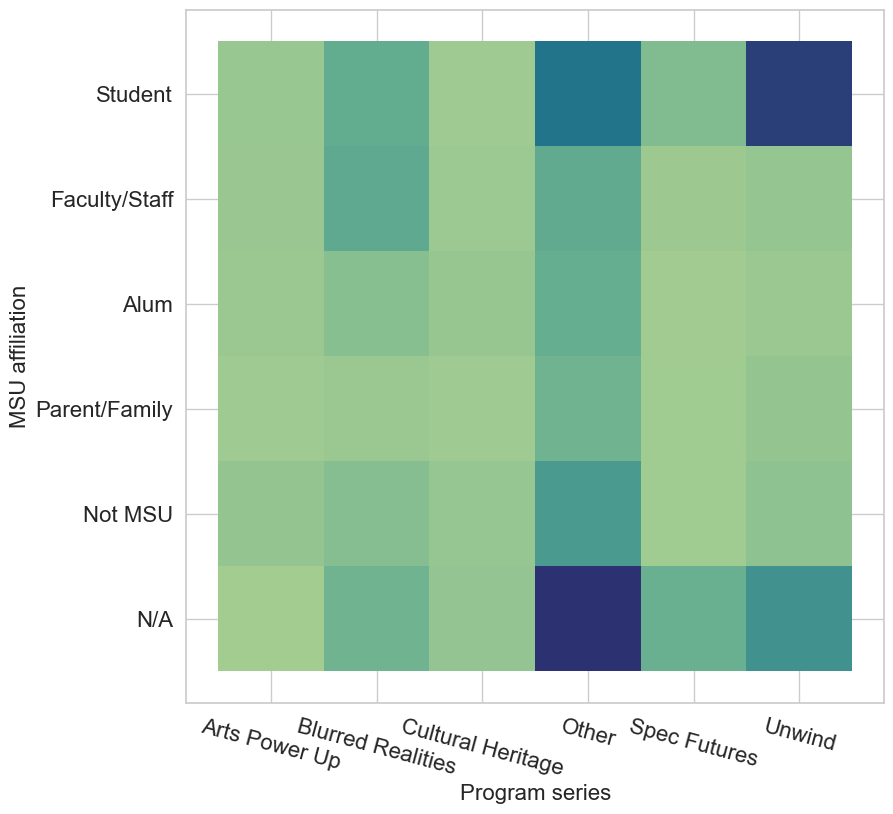

In [40]:
attendees = registrants.loc[registrants['Attended'] == True]

fig, ax = plt.subplots(figsize=(9,9))
fig = sns.histplot(attendees, x='Program series', y='MSU affiliation', cmap='crest')
fig.set_xticklabels(fig.get_xticklabels(), rotation=345)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.xaxis.label.set_size(16)
ax.yaxis.label.set_size(16)
fig.figure.savefig(q_dir+"/2D-affil-series.png", bbox_inches='tight')
plt.show()

In [41]:
students_attended = attendees.loc[attendees['MSU affiliation'] == "N/A"]
for i in range(len(programs['Name'])):
    prog_loc = students_attended['Program name'].str.contains(programs.loc[i, 'Name'], case=False)
    tots = len(students_attended.loc[prog_loc, 'Program series'])
    print("%s %d" % (programs.loc[i,'Name'], tots))

MSU Museum Reopening & "Blurred Realities" Exhibition Reception 104
Fake News! The Battle for Truth in a Disinformation Age 1
Reality Check: Spotting AI Shenanigans 1
XOXO, Let's Connect 0
AI and the Body in the Age of Noise 0
AI-Biographies 1
Visual Realities 1
AI, Elections, and the Fight for Facts 0
Clone of the Dance 0
"Blurred Realities" Poetry Slam 6
Gallery Talk: Museum of Alternative History 0
Ignite Talks MSU 5 3
Ignite Talks MSU 6 0
Beyond Borders: A Conversation with Dr. Fredrick Luis Aldama 12
Beyond Borders: Oral History with Dr. Fredrick Luis Aldama 6
Echoes of the Earth: Native American Drumming Traditions-Talk 14
Echoes of the Earth: Native American Drumming Traditions- AM Workshop 3
Echoes of the Earth: Native American Drumming Traditions- PM Workshop 4
Salt: A Ripple Effect 7
Made in Detroit: Carl Craig and Rodney Whitaker in Conversation 4
Conversation: Music, Science, and Video Games 1
"Physical Spells" Opening Reception 0
Ascent Act II 45
Hard Hat Tour 22
SciCuriou

## MSU affiliation

Let's clean the registrant data and make a new dataframe where each individal is listed once, and we sum the number of pre-registrations and attendances they had.

In [42]:
reg_by_name = pd.DataFrame(columns=('Visitor name', 'Attended', 'Preregistered', 'Percentage', 'Host name', 'MSU affiliation'))
reg_by_name['Visitor name'] = registrants['Visitor name'].unique()
nas_with_other = 0
for i in range(len(reg_by_name['Visitor name'])):
    appearances = registrants['Visitor name'].values == reg_by_name.loc[i, 'Visitor name']
    reg_by_name.loc[i, 'Preregistered'] = sum(appearances) # sum of times it appears in the whole registrants list, plus guests
    reg_by_name.loc[i, 'Attended'] = sum(registrants.loc[appearances, 'Attended'])#sum of attended where name == visitors name
    affil = registrants.loc[appearances, 'MSU affiliation'].unique()
    if len(affil) > 1 and "N/A" in affil:
        reg_by_name.loc[i, 'MSU affiliation'] = np.delete(affil, np.where(affil == 'N/A'))[0]
        nas_with_other += 1
    else:
        reg_by_name.loc[i, 'MSU affiliation'] = affil[0]
reg_by_name['Percentage'] = reg_by_name['Attended'] / reg_by_name['Preregistered']
reg_by_name['MSU affiliation'] = pd.Categorical(reg_by_name['MSU affiliation'], categories=affil_cats, ordered=True)

In [43]:
tot_reg = sum(reg_by_name['Preregistered'])
uniq_reg = len(reg_by_name)
tot_att = sum(reg_by_name['Attended'])
mult_attend = reg_by_name.iloc[np.where(reg_by_name['Attended'] > 1)[0]]
#display(mult_attend)
attended_once = len(np.where(reg_by_name['Attended'] == 1)[0])
#print(attended_once)
all_guests = np.where(mult_attend['Visitor name'].str.contains("Guest")) 
not_guests = np.where(mult_attend['Visitor name'].str.contains("Guest") == False)
repeat_attender = len(mult_attend.iloc[not_guests])
#print(repeat_attender)
sum_guests = sum(mult_attend['Attended'].iloc[all_guests]) # assume all guests are unique attendees
#print(sum_guests)             
uniq_att = attended_once + repeat_attender + sum_guests
#print(uniq_att)

In [44]:
print("Across all programs this quarter, there were %d pre-registrants (%d unique pre-registrants) "\
      "and %d attendees (%d unique attendees)." % \
      (tot_reg, uniq_reg, tot_att, uniq_att))

Across all programs this quarter, there were 5759 pre-registrants (4257 unique pre-registrants) and 3723 attendees (3297 unique attendees).


In [45]:
affil_gb = reg_by_name.groupby('MSU affiliation', observed=False)

In [46]:
for affil in affil_cats:
    print("%d %s (%d pre-registrants; %.0f%% attendance)" % (affil_gb['Attended'].get_group(affil).sum(), 
                                                             affil,
                                                             affil_gb['Preregistered'].get_group(affil).sum(), 
                                                             affil_gb['Percentage'].get_group(affil).mean()*100))

1202 Student (1793 pre-registrants; 69% attendance)
408 Faculty/Staff (662 pre-registrants; 61% attendance)
285 Alum (493 pre-registrants; 59% attendance)
214 Parent/Family (400 pre-registrants; 55% attendance)
416 Not MSU (766 pre-registrants; 56% attendance)
1147 N/A (1580 pre-registrants; 70% attendance)


In [47]:
print("\tPre-registrants by MSU affiliation:")
display(affil_gb['Preregistered'].sum())

	Pre-registrants by MSU affiliation:


MSU affiliation
Student          1793
Faculty/Staff     662
Alum              493
Parent/Family     400
Not MSU           766
N/A              1580
Name: Preregistered, dtype: object

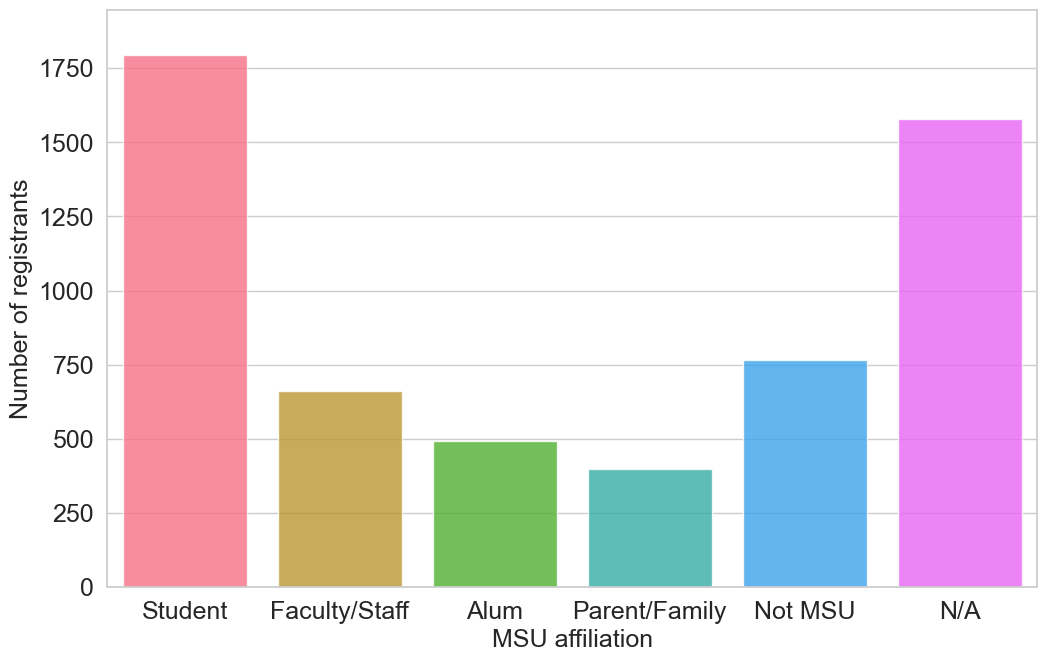

In [48]:
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(12,7.5))
sns.set_palette("husl")
fig = sns.barplot(data=reg_by_name, x='MSU affiliation', y='Preregistered', palette='husl', 
                  hue='MSU affiliation', estimator=sum, saturation=1, alpha=0.8, err_kws={'linewidth': 0})
ax.set(xlabel="MSU affiliation", ylabel="Number of registrants")
ax.get_legend().remove()
ax.tick_params(axis='both', which='major', labelsize=18)
ax.xaxis.label.set_size(18)
ax.yaxis.label.set_size(18)
fig.figure.savefig(q_dir+"/pre-reg_affil_bar.png", bbox_inches='tight')
plt.show()

In [49]:
print("\tAttendees by MSU affiliation:")
display(affil_gb['Attended'].sum())

	Attendees by MSU affiliation:


MSU affiliation
Student          1202
Faculty/Staff     408
Alum              285
Parent/Family     214
Not MSU           416
N/A              1147
Name: Attended, dtype: object

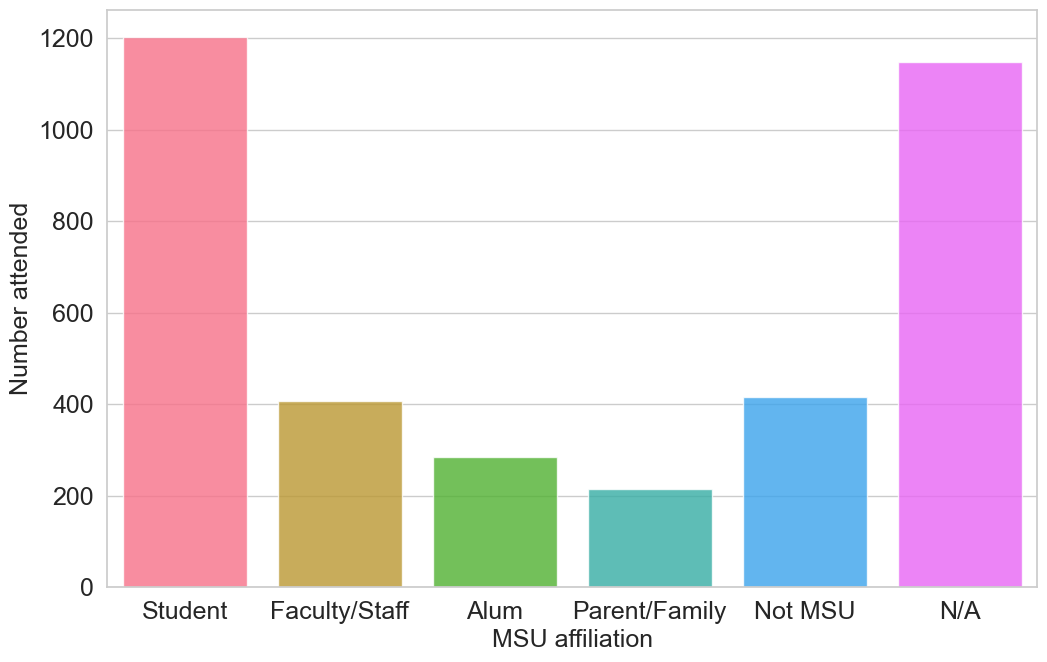

In [50]:
fig, ax = plt.subplots(figsize=(12,7.5))
fig = sns.barplot(data=reg_by_name, x='MSU affiliation', y='Attended', palette='husl', 
                  hue='MSU affiliation', estimator='sum', saturation=1, alpha=0.8, errorbar=None)
ax.set(xlabel="MSU affiliation", ylabel="Number attended")
ax.get_legend().remove()
ax.tick_params(axis='both', which='major', labelsize=18)
ax.xaxis.label.set_size(18)
ax.yaxis.label.set_size(18)
fig.figure.savefig(q_dir+"/attend_affil_bar.png", bbox_inches='tight')
plt.show()

In [51]:
display(affil_gb['Percentage'].mean())

MSU affiliation
Student          0.692439
Faculty/Staff    0.606963
Alum             0.587309
Parent/Family    0.546339
Not MSU           0.56189
N/A               0.69998
Name: Percentage, dtype: object

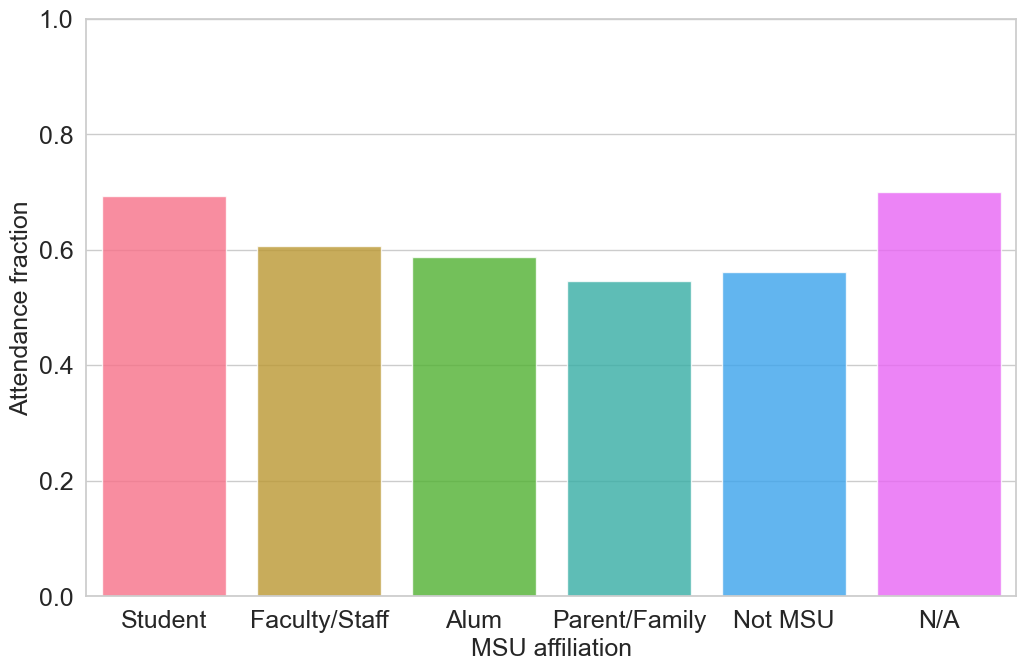

In [52]:
fig, ax = plt.subplots(figsize=(12,7.5))
fig = sns.barplot(data=reg_by_name, x='MSU affiliation', y='Percentage', palette='husl', 
                  hue='MSU affiliation', saturation=1, alpha=0.8, errorbar=None)
ax.set(xlabel="MSU affiliation", ylabel="Attendance fraction", ylim=(0,1))
ax.get_legend().remove()
ax.tick_params(axis='both', which='major', labelsize=18)
ax.xaxis.label.set_size(18)
ax.yaxis.label.set_size(18)
fig.figure.savefig(q_dir+"/percent_affil_bar.png", bbox_inches='tight')
plt.show()